# AMAS exam 2025
Chamilla Terp, UCPH ID: bmx626 <br>
Date: 27th - 28th of March 2025

In [619]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import beta
import pandas as pd
import scipy.integrate as integrate
from iminuit import Minuit 
from matplotlib.patches import ConnectionPatch  
from tqdm.notebook import tqdm

colors = ['#41AFAA', '#466EB4', '#00A0E1', '#E6A532', '#D7642C', '#AF4B91']

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 13,
})

# For nested fitting
import ultranest
from ultranest.plot import cornerplot
from ultranest.plot import PredictionBand


In [620]:
def chi_squared_test(data, func, params, num_bins):
    """ Used for non-discrete data. """

    counts, bins = np.histogram(data, bins = num_bins)
    bin_centers = (bins[1:] + bins[:-1]) / 2
    bin_width = bins[1] - bins[0]

    # Poisson errors
    errors = np.sqrt(counts)

    # Removing bins with zero counts
    x = bin_centers[counts > 0]
    y = counts[counts > 0]
    errors = errors[counts > 0]

    # Expected values
    y_exp = func(x, *params) * len(data) * bin_width

    # Degrees of freedom
    ddof = len(x) - len(params)

    # Calculating chi-squared and p-value
    chi_squared = np.sum((y - y_exp) ** 2 / y_exp)
    chi_squared_reduced = chi_squared / ddof
    p_value = stats.chi2.sf(chi_squared, df = ddof)
    print(f'Reduced chi-squared: {chi_squared_reduced:.4f}, p-value: {p_value:.4f}')

    return chi_squared_reduced, p_value, bin_width

def chi2_hist_discrete(data, func, params, num_bins):
    """ Used for discrete data."""

    counts, bins = np.histogram(data, bins = np.arange(-0.5, num_bins, 1))
    bin_centers = (bins[1:] + bins[:-1]) / 2
    bin_width = bins[1] - bins[0]

    # Poisson errors
    errors = np.sqrt(counts)

    # Removing bins with zero counts
    x = bin_centers[counts > 0]
    y = counts[counts > 0]
    errors = errors[counts > 0]

    # Expected values
    y_exp = func(x, *params) * len(data) * bin_width

    dof = len(x) - len(params)

    # Calculating chi-squared and p-value
    chi_squared = np.sum((y - y_exp) ** 2 / y_exp)
    chi_squared_reduced = chi_squared / dof
    p_value = stats.chi2.sf(chi_squared, df = dof)
    print(f'Reduced chi-squared: {chi_squared_reduced:.4f}, p-value: {p_value:.4f}')

    return chi_squared_reduced, p_value, bin_width

In [621]:
# Unbinned likelihood
def unbinned_likelihood(data, likelihood, param_guess, params_names, param_limits = None, step = False, alpha_range = None, beta_range = None, verbose = False):
    steps = []

    def neg_log_likelihood(params):
        """Used for Minuit."""
        steps.append(params)
        neg_llh = -np.sum(np.log(likelihood(data, *params)))
        return neg_llh
    
    minuit_negllh = Minuit(neg_log_likelihood, param_guess, name = params_names)

    if param_limits:
        for i in range(len(param_limits)):
            minuit_negllh.limits[i] = param_limits[i]

    minuit_negllh.errordef = 0.5     
    minuit_negllh.migrad()

    if verbose: print(minuit_negllh.migrad())
    if (not minuit_negllh.fmin.is_valid):
        print("  WARNING: The Unbinned Likelihood fit DID NOT converge. ")

    par = minuit_negllh.values[:]
    par_err = minuit_negllh.errors[:]
    par_name = minuit_negllh.parameters[:]
    negLLH_val = minuit_negllh.fval
    dof_value = len(data) - minuit_negllh.nfit

    if step: 
        def find_nearest(a, a0):
            idx = np.abs(a - a0).argmin()
            return idx
        
        alpha_step = []
        beta_step = []

        for step in range(len(steps)):
            alpha_step.append(alpha_range[find_nearest(alpha_range, steps[step][0])])
            beta_step.append(beta_range[find_nearest(beta_range, steps[step][1])])
                             
        return par, par_err, alpha_step, beta_step

    else:
        return par, par_err, negLLH_val

## Problem 1

Inspired by solution by Kimi Kreilgaard: https://github.com/KimiKreil/Advanced-Methods-in-Applied-Statistics.

In [622]:
prob_1_data = pd.read_csv('https://www.nbi.dk/~koskinen/Teaching/AdvancedMethodsInAppliedStatistics2025/data/Exam_2025_Prob1.txt', delim_whitespace = True, header = None)

/var/folders/ws/45wzf3p157x_56fnsrq6bc4w0000gn/T/ipykernel_73318/1324117269.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  prob_1_data = pd.read_csv('https://www.nbi.dk/~koskinen/Teaching/AdvancedMethodsInAppliedStatistics2025/data/Exam_2025_Prob1.txt', delim_whitespace = True, header = None)


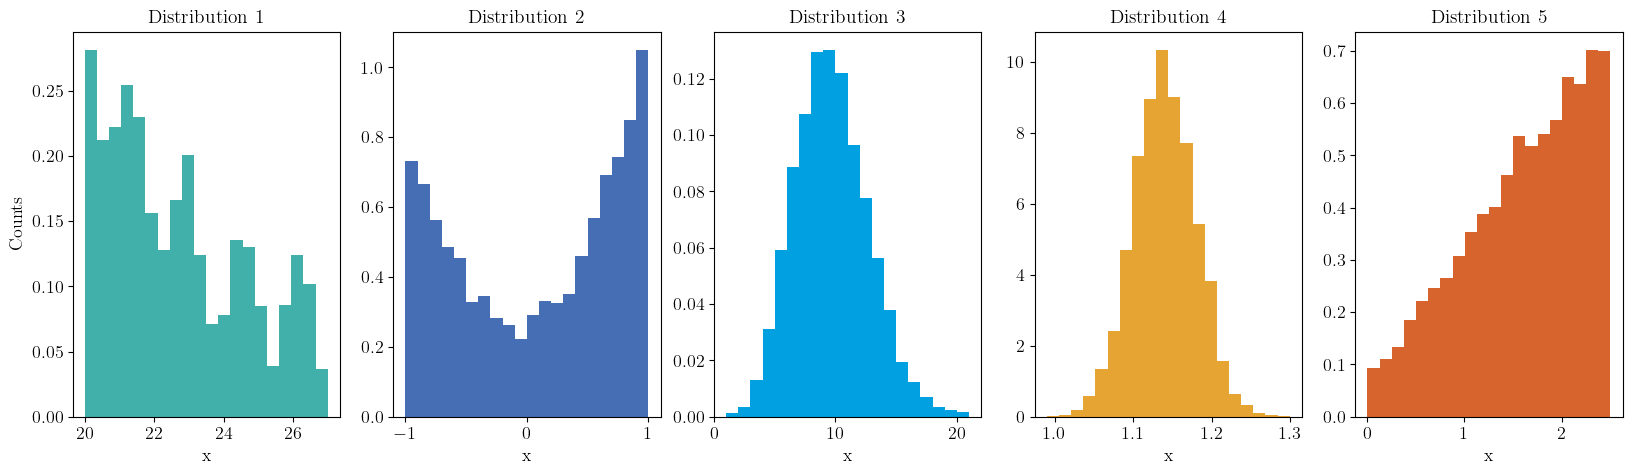

In [623]:
# Plotting all five distributions (i.e. columns) in the data
fig, ax = plt.subplots(1, 5, figsize = (20, 5))

for i in range(5):
    ax[i].hist(prob_1_data[i], bins = 20, color = colors[i], density = True)
    ax[i].set_title(f'Distribution {i+1}', fontsize = 14)
    ax[i].set_xlabel('x', fontsize = 13)

ax[0].set_ylabel('Counts', fontsize = 13)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/distributions_prob_1.png', dpi = 300)
plt.show()

### Problem 1a

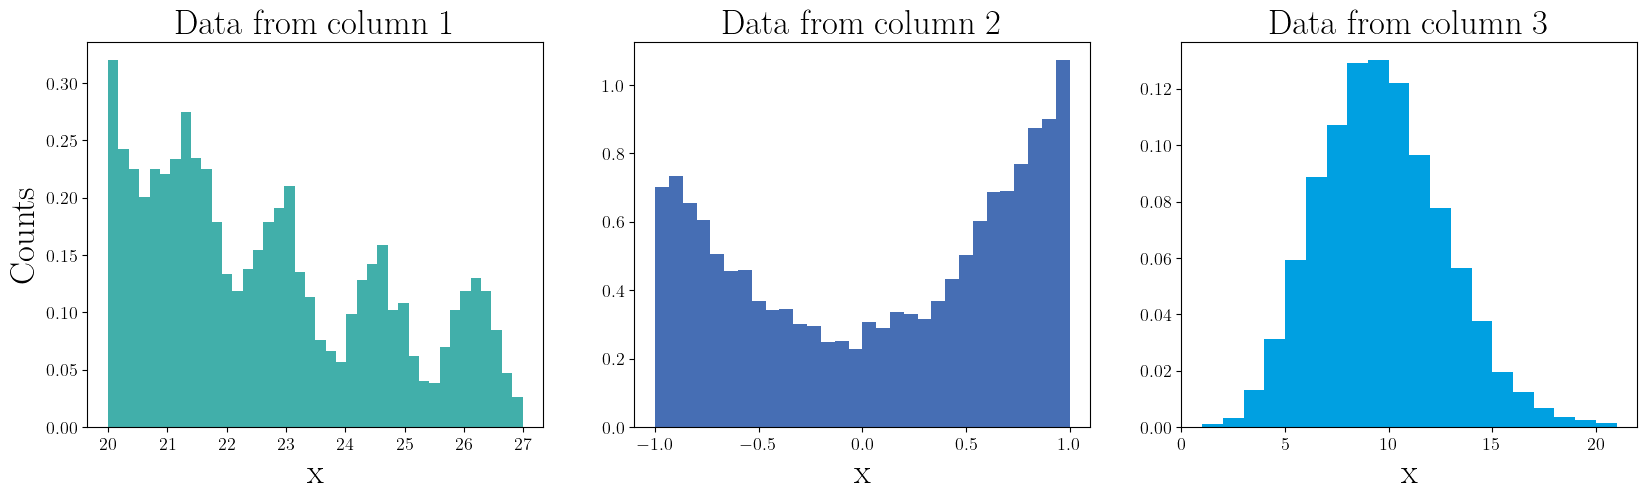

In [624]:
# Plotting only the first, second and third distribution
fig, ax = plt.subplots(1, 3, figsize = (20, 5))

for i in range(3):
    if i == 0:
        bins = 40
    elif i == 1:
        bins = 30
    else:
        bins = 20

    ax[i].hist(prob_1_data[i], bins = bins, color = colors[i], density = True)
    ax[i].set_title(f'Data from column {i+1}', fontsize = 25)
    ax[i].set_xlabel('x', fontsize = 25)

ax[0].set_ylabel('Counts', fontsize = 25)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/distributions_prob_1a.png', dpi = 300)
plt.show()

#### Fitting first distribution

In [625]:
# Imposing the bounds/ranges
x_range_1 = (20, 27)
x_data_1 = np.linspace(x_range_1[0], x_range_1[1], 1000) 

params_1 = ['a', 'b', 'c']
params_range_1 = [(-10, 10), (-10, 10), (4000, 8000)]

def func_1(x, a, b, c):
    """ 
    The parameters a, b, and c are the parameters of the function to be fitted. They are only valid in these ranges:  
    a: [-10, 10], b: [-10, 10], c: [4000, 8000]
    """
    f = np.sin(a * x) + c * np.exp(b * x) + 1
    norm = np.trapz(np.sin(a * x_data_1) + c * np.exp(b * x_data_1) + 1, x_data_1)

    f_norm = f / norm
    return f_norm

Following the UltraNest documentation and guide: https://johannesbuchner.github.io/UltraNest/index.html.

In [626]:
# Using nested sampling to fit the first distribution
# First: defining the prior
def prior(cube):
    params = cube.copy()

    # Transforming the cube values to the parameter values
    lower_bound, upper_bound = params_range_1[0][0], params_range_1[0][1]
    params[0] = cube[0] * (upper_bound - lower_bound) + lower_bound

    lower_bound, upper_bound = params_range_1[1][0], params_range_1[1][1]
    params[1] = cube[1] * (upper_bound - lower_bound) + lower_bound

    lower_bound, upper_bound = params_range_1[2][0], params_range_1[2][1]
    params[2] = cube[2] * (upper_bound - lower_bound) + lower_bound

    return params

# Second: defining the log likelihood
def log_likelihood(params): 
    model = func_1(prob_1_data[0], *params)
    llh = np.sum(np.log(model))
    return llh

In [627]:
# Sampling
sampler_1 = ultranest.ReactiveNestedSampler(params_1, log_likelihood, prior)

N = 1000 
result_1 = sampler_1.run(min_num_live_points = N, dKL = 0.5, max_num_improvement_loops = 1000)
sampler_1.print_results()

[ultranest] Sampling 1000 live points from prior ...


[ultranest] Explored until L=-9e+03  302.01 [-9302.0451..-9302.0451]*| it/evals=21100/318802 eff=6.6394% N=1000    
[ultranest] Likelihood function evaluations: 318886
[ultranest]   logZ = -9319 +- 0.09365
[ultranest] Effective samples strategy satisfied (ESS = 4324.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.04 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.09, need <0.5)
[ultranest]   logZ error budget: single: 0.12 bs:0.09 tail:0.01 total:0.09 required:<0.50
[ultranest] done iterating.

logZ = -9318.585 +- 0.152
  single instance: logZ = -9318.585 +- 0.124
  bootstrapped   : logZ = -9318.593 +- 0.152
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 3.8910│ ▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▅▄▄▂▂▂▁▁▁▁▁▁▁▁ ▁ │3.9082    3.8992 +- 0.0019
    b                   : -0.3861│ ▁ ▁▁▁▁▂▂▅▆▇▇▇▇▇▇▆▅▅▄▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁ ▁ │-0.3237    -0.3594 +- 0.0086
    c  

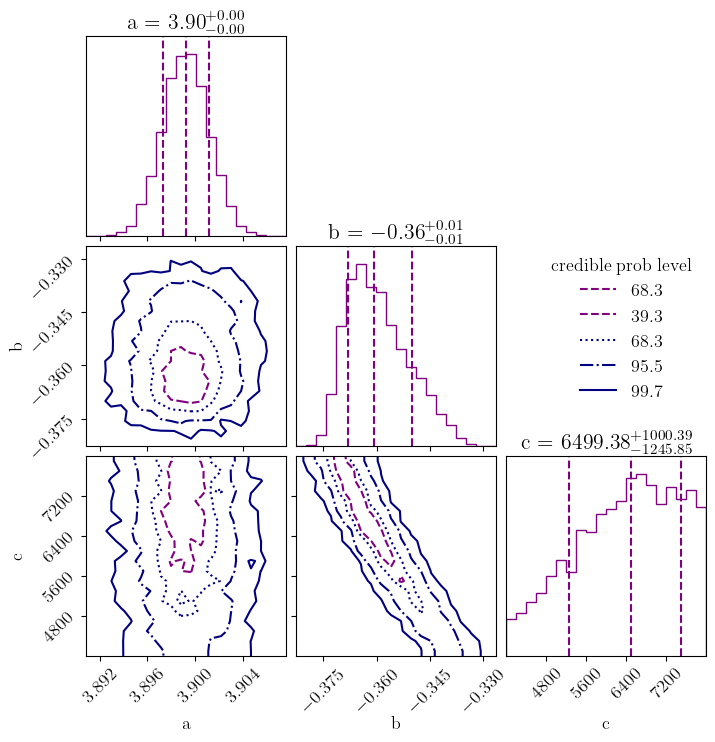

In [628]:
# Plotting the cornerplot to see results
cornerplot(result_1)


plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/cornerplot_prob_1a.png', dpi = 300)

In [629]:
# Defining function for printing the results
def print_results(name_param, param):
    n = len(param)

    # Sorting the parameters
    param_sorted = np.sort(param)
    mean = np.mean(param)

    # Calculating the 68% confidence interval
    low = (1 - 0.68) / 2
    high = 1 - low

    low_index = int(low * n)
    high_index = int(high * n)

    lower_uncertainty = np.mean(param_sorted) - param_sorted[low_index]
    upper_uncertainty = param_sorted[high_index] - np.mean(param_sorted)

    print(f'{name_param} = {mean:.4f} + {upper_uncertainty:.4f} - {lower_uncertainty:.4f}')
    return mean, upper_uncertainty, lower_uncertainty

# Printing the results
fit_dist_1 = pd.DataFrame(data = result_1['samples'], columns = params_1)

a_mean, a_upper, a_lower = print_results('a', fit_dist_1['a'])
b_mean, b_upper, b_lower = print_results('b', fit_dist_1['b'])
c_mean, c_upper, c_lower = print_results('c', fit_dist_1['c'])

a = 3.8992 + 0.0019 - 0.0019
b = -0.3594 + 0.0094 - 0.0086
c = 6390.9144 + 1105.8740 - 1133.0386


In [630]:
# Performing a chi-squared test to see if the model fits the data
num_bins = 100

# Checking minimum counts
counts, bin_edges = np.histogram(prob_1_data[0], bins = num_bins)
print(f'Minimum counts: {np.min(counts)}')

chi_1, p_1, bin_width_1 = chi_squared_test(prob_1_data[0], func_1, [a_mean, b_mean, c_mean], num_bins)

Minimum counts: 8
Reduced chi-squared: 0.7962, p-value: 0.9306


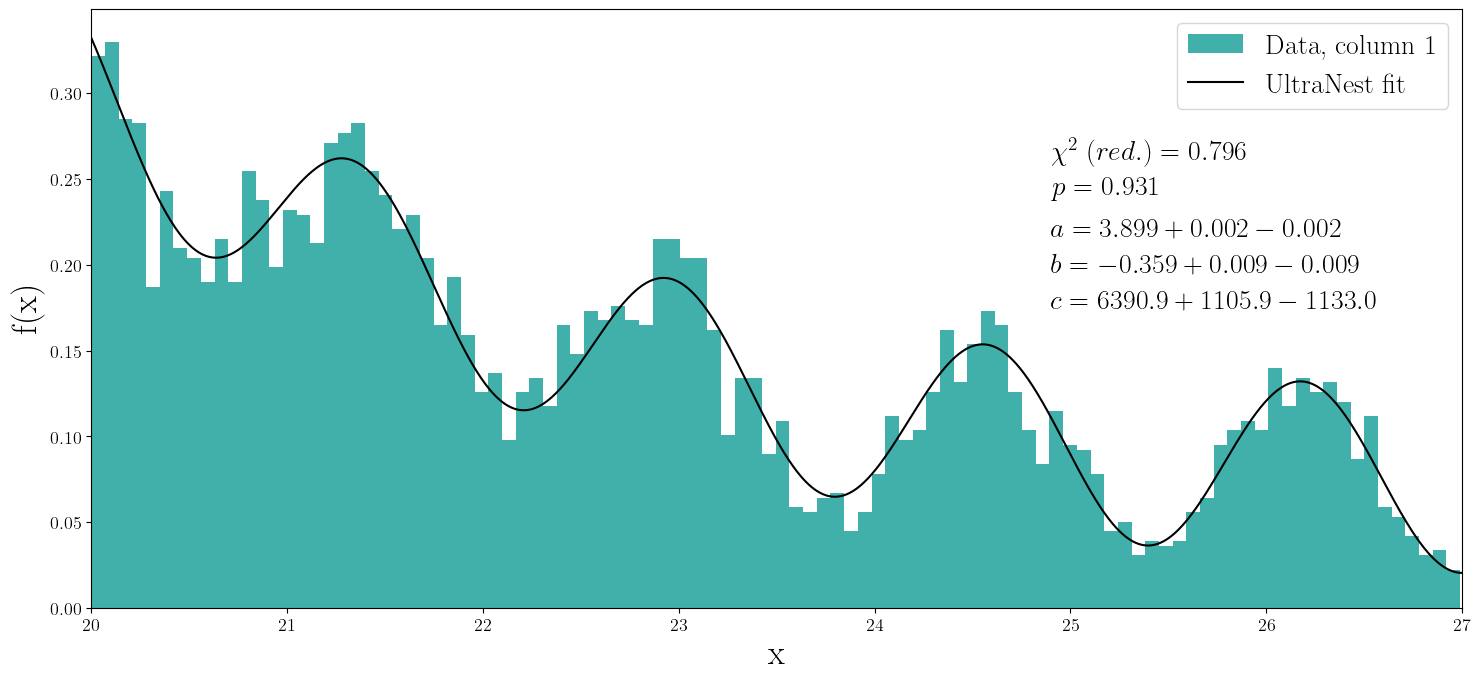

In [738]:
# Plotting the distribution with the fitted model
fig, ax = plt.subplots(1, 1, figsize = (15, 7))

ax.hist(prob_1_data[0], bins = num_bins, color = colors[0], density = True, label = 'Data, column 1')

# Plotting fit
ax.plot(x_data_1, func_1(x_data_1, a_mean, b_mean, c_mean), color = 'black', label = 'UltraNest fit')

ax.set_xlabel('x', fontsize = 25)
ax.set_ylabel('f(x)', fontsize = 25)
ax.set_xlim(20, 27)

ax.legend(fontsize = 20)

ax.annotate(f'$\chi^2 \; (red.) = {chi_1:.3f}$', xy = (0.7, 0.75), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$p                = {p_1:.3f}$', xy = (0.7, 0.69), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$a                = {a_mean:.3f} + {a_upper:.3f} - {a_lower:.3f}$', xy = (0.7, 0.62), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$b                = {b_mean:.3f} + {b_upper:.3f} - {b_lower:.3f}$', xy = (0.7, 0.56), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$c                = {c_mean:.1f} + {c_upper:.1f} - {c_lower:.1f}$', xy = (0.7, 0.50), xycoords = 'axes fraction', fontsize = 20)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/fit_prob_1a_1.png', dpi = 300)

#### Fitting second distribution

In [707]:
# Imposing the bounds/ranges
x_range_2 = (-1, 1)
x_data_2 = np.linspace(x_range_2[0], x_range_2[1], 1000) 

params_2 = ['a', 'b']
params_range_2 = [(-10, 10), (-10, 10)]

def func_2(x, a, b):
    f = 1 + a * x + b * x ** 2
    # Analytical normalization (integral)
    norm = 2 + ((2/3) * b)
    f_norm = f / norm
    return f_norm

In [708]:
# Using the unbinned likelihood method
fit_par_2, fit_par_err_2, neg_LLH_2 = unbinned_likelihood(prob_1_data[1], func_2, [0, 0], params_2)

In [709]:
# Performing a chi-squared test to see if the model fits the data
num_bins = 100

# Checking minimum counts
counts, bin_edges = np.histogram(prob_1_data[1], bins = num_bins)
print(f'Minimum counts: {np.min(counts)}')

chi_2, p_2, bin_width_2 = chi_squared_test(prob_1_data[1], func_2, fit_par_2, num_bins)

Minimum counts: 16
Reduced chi-squared: 0.8372, p-value: 0.8769


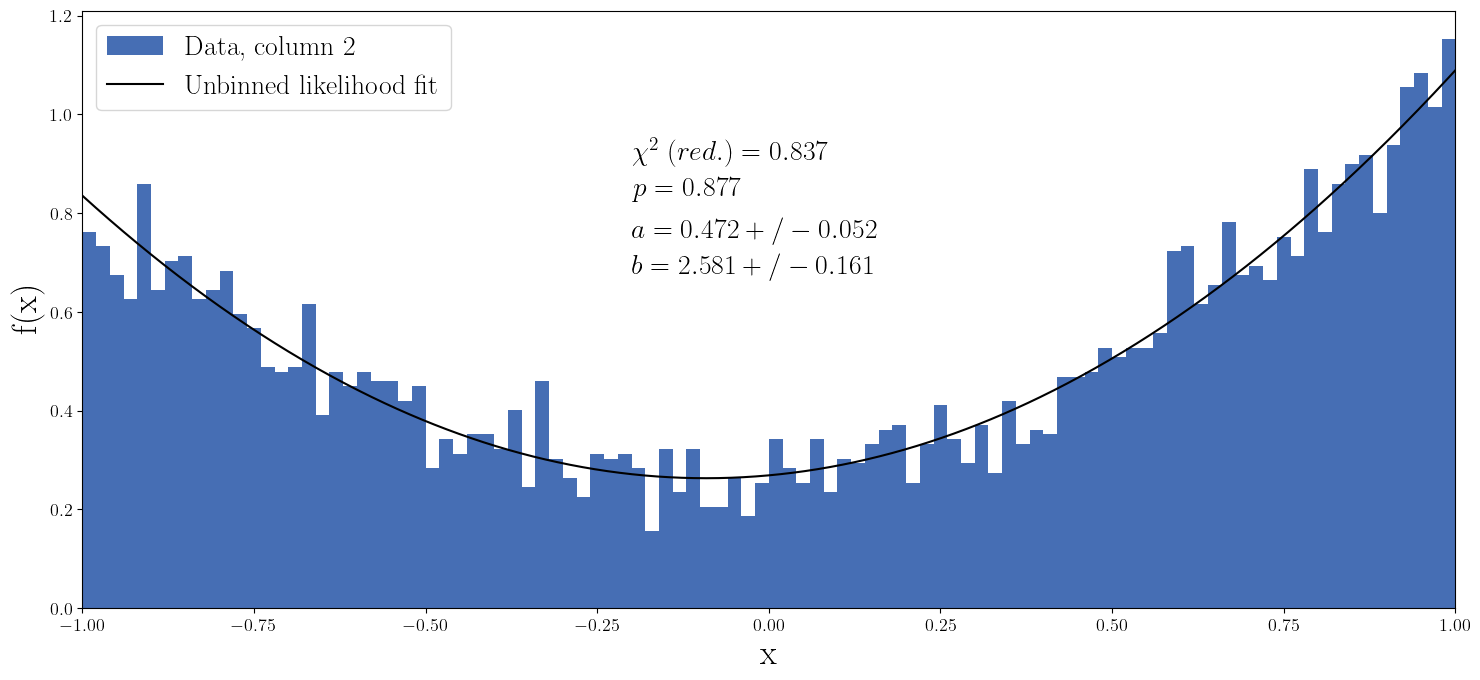

In [739]:
# Plotting the distribution with the fitted model
fig, ax = plt.subplots(1, 1, figsize = (15, 7))

ax.hist(prob_1_data[1], bins = num_bins, color = colors[1], density = True, label = 'Data, column 2')

# Plotting fit
ax.plot(x_data_2, func_2(x_data_2, *fit_par_2), color = 'black', label = 'Unbinned likelihood fit')

ax.set_xlabel('x', fontsize = 25)
ax.set_ylabel('f(x)', fontsize = 25)
ax.set_xlim(-1, 1)

ax.legend(fontsize = 20)

a_mean_2, a_err = fit_par_2[0], fit_par_err_2[0]
b_mean_2, b_err = fit_par_2[1], fit_par_err_2[1]

ax.annotate(f'$\chi^2 \; (red.) = {chi_2:.3f}$', xy = (0.4, 0.75), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$p                = {p_2:.3f}$', xy = (0.4, 0.69), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$a                = {a_mean_2:.3f} +/- {a_err:.3f}$', xy = (0.4, 0.62), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$b                = {b_mean_2:.3f} +/- {b_err:.3f} $', xy = (0.4, 0.56), xycoords = 'axes fraction', fontsize = 20)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/fit_prob_1a_2.png', dpi = 300)

#### Fitting third distribution

In [636]:
# Testing both a binomial and poisson distribution

# Imposing the bounds/ranges
x_range_3 = (0, 30)
x_data_3 = np.linspace(x_range_3[0], x_range_3[1], x_range_3[1] + 1)

# Binomial distribution
params_binom = ['p', 'n']

# Poisson distribution
params_poisson = ['lambda']

In [637]:
# Defining the functions (as they are PDFs they are normalized)
def binom(x, p, n):
    f = stats.binom.pmf(x, n, p)
    return f

def poisson(x, lambd):
    f = stats.poisson.pmf(x, lambd)
    return f

In [638]:
# Using the unbinned likelihood method
fit_par_binom, fit_par_err_binom, neg_LLH_binom = unbinned_likelihood(prob_1_data[2], binom, [0.0008, 10800], params_binom)
fit_par_poisson, fit_par_err_poisson, neg_LLH_poisson = unbinned_likelihood(prob_1_data[2], poisson, [10], params_poisson)

In [639]:
# Performing a chi-squared test to see if the model fits the data (discrete data)
num_bins = 30

# Binomial
print('------ Binomial ------')
chi_binom, p_binom, bin_width_binom = chi2_hist_discrete(prob_1_data[2], binom, fit_par_binom, num_bins)

# Poisson
print('------ Poisson ------')
chi_poisson, p_poisson, bin_width_poisson = chi2_hist_discrete(prob_1_data[2], poisson, fit_par_poisson, num_bins)


------ Binomial ------
Reduced chi-squared: 10.3010, p-value: 0.0000
------ Poisson ------
Reduced chi-squared: 0.5530, p-value: 0.9447


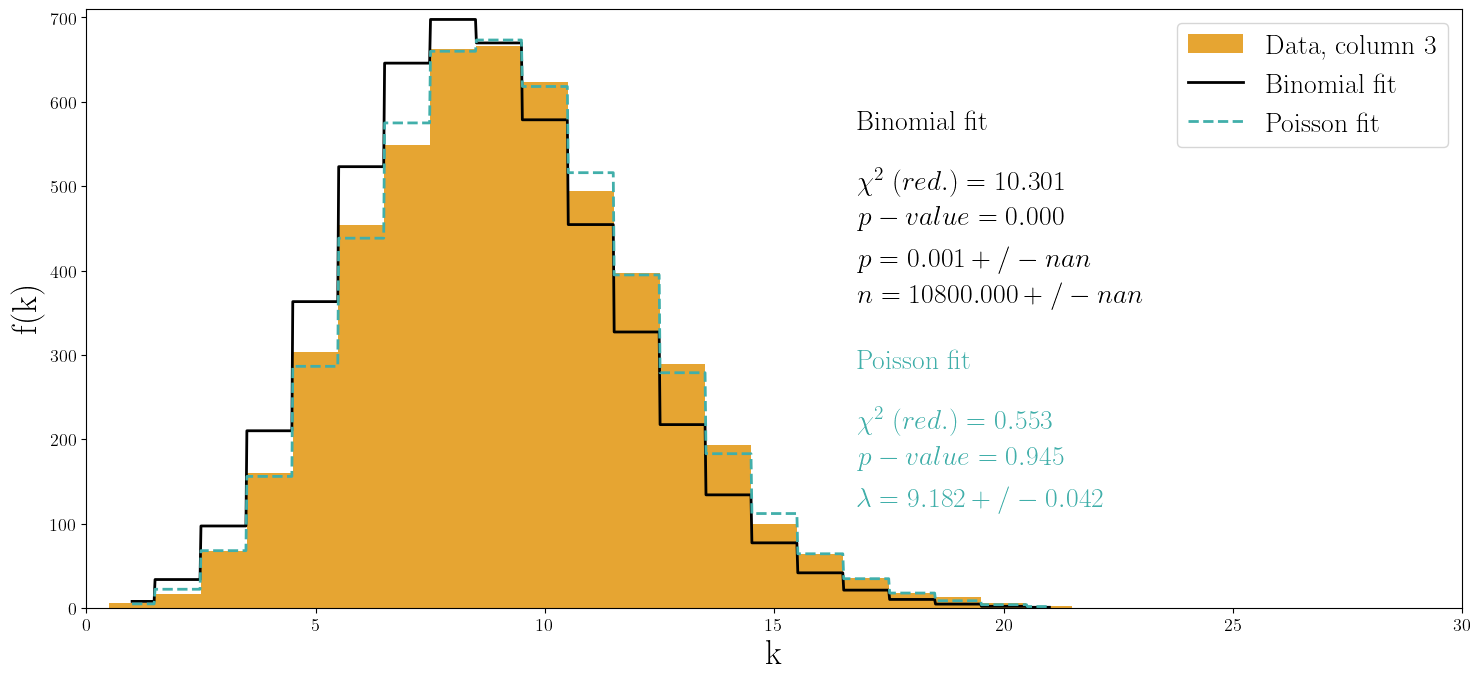

In [737]:
# Plotting the distribution with the fitted models
fig, ax = plt.subplots(1, 1, figsize = (15, 7))

ax.hist(prob_1_data[2], bins = np.arange(-0.5, x_range_3[1], 1), color = colors[3], zorder = 2, label = 'Data, column 3')

x_array = np.linspace(min(prob_1_data[2]), max(prob_1_data[2]), 1000)
# Plotting fit (Binomial)
ax.plot(x_array, binom(np.floor(x_array + 0.5), *fit_par_binom) * len(prob_1_data[2]) * bin_width_binom, color = 'black', zorder = 3, linewidth = 2, label = 'Binomial fit')

# Plotting fit (Poisson)
ax.plot(x_array, (poisson(np.floor(x_array + 0.5), *fit_par_poisson) * len(prob_1_data[2]) * bin_width_poisson), color = colors[0], zorder = 3, linestyle = 'dashed', linewidth = 2, label = 'Poisson fit')

ax.set_xlabel('k', fontsize = 25)
ax.set_ylabel('f(k)', fontsize = 25)
ax.set_xlim(0, 30)
ax.set_ylim(-0.001, 710)

ax.legend(loc = 'upper right', fontsize = 20)

p_mean_binom, n_mean_binom = fit_par_binom[0], fit_par_binom[1]
p_err_binom, n_err_binom = fit_par_err_binom[0], fit_par_err_binom[1]

lambda_mean_poisson, lambda_err_poisson = fit_par_poisson[0], fit_par_err_poisson[0]

ax.annotate('Binomial fit', xy = (0.56, 0.8), xycoords = 'axes fraction', fontsize = 20, color = 'black')
ax.annotate(f'$\chi^2 \; (red.) = {chi_binom:.3f}$', xy = (0.56, 0.7), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$p-value          = {p_binom:.3f}$', xy = (0.56, 0.64), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$p                = {p_mean_binom:.3f} +/- {p_err_binom:.3f}$', xy = (0.56, 0.57), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$n                = {n_mean_binom:.3f} +/- {n_err_binom:.3f}$', xy = (0.56, 0.51), xycoords = 'axes fraction', fontsize = 20)

ax.annotate('Poisson fit', xy = (0.56, 0.4), xycoords = 'axes fraction', fontsize = 20, color = colors[0])
ax.annotate(f'$\chi^2 \; (red.) = {chi_poisson:.3f}$', xy = (0.56, 0.3), xycoords = 'axes fraction', fontsize = 20, color = colors[0])
ax.annotate(f'$p-value          = {p_poisson:.3f}$', xy = (0.56, 0.24), xycoords = 'axes fraction', fontsize = 20, color = colors[0])
ax.annotate(f'$\lambda = {lambda_mean_poisson:.3f} +/- {lambda_err_poisson:.3f}$', xy = (0.56, 0.17), xycoords = 'axes fraction', fontsize = 20, color = colors[0])

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/fit_prob_1a_3.png', dpi = 300)
plt.show()

## Problem 2

Part of the code used in this problem, have been inspired by Kimi Kreilgaard. Her code can be found here: https://github.com/KimiKreil/Advanced-Methods-in-Applied-Statistics. It also follows the lecture notes found here: https://www.nbi.dk/~koskinen/Teaching/AdvancedMethodsInAppliedStatistics2025/Lecture_AhlersKoskinen2025.pdf (specifically slides 28-34). 

In [641]:
prob_2_data = np.genfromtxt('https://www.nbi.dk/~koskinen/Teaching/AdvancedMethodsInAppliedStatistics2025/data/Exam_2025_Problem2.txt', skip_header = 1)
#print(prob_2_data)

azimuth = prob_2_data[:,0]
zenith = prob_2_data[:,1]

In [642]:
def projection(azimuth, zenith, ax, title, colors):
    ax.set_facecolor('gainsboro')
    ax.grid(color = 'black', linestyle = '--', linewidth = 0.5)

    # Meridian and equator
    meridian = np.stack([np.zeros(100), np.linspace(0, np.pi, 100) - np.pi / 2], axis = 1)
    equator = np.stack([np.linspace(0, 2 * np.pi, 100) - np.pi, np.zeros(100)], axis = 1)

    ax.plot(meridian[:,0], meridian[:,1], color = 'black', linestyle = '--', linewidth = 0.5)
    ax.plot(equator[:,0], equator[:,1], color = 'black', linestyle = '--', linewidth = 0.5)

    # Plotting the data
    ax.scatter(azimuth - np.pi, -zenith + np.pi / 2, marker = 'P', color = colors, s = 30, zorder = 2, label = 'Data')

    ax.set_title(title)

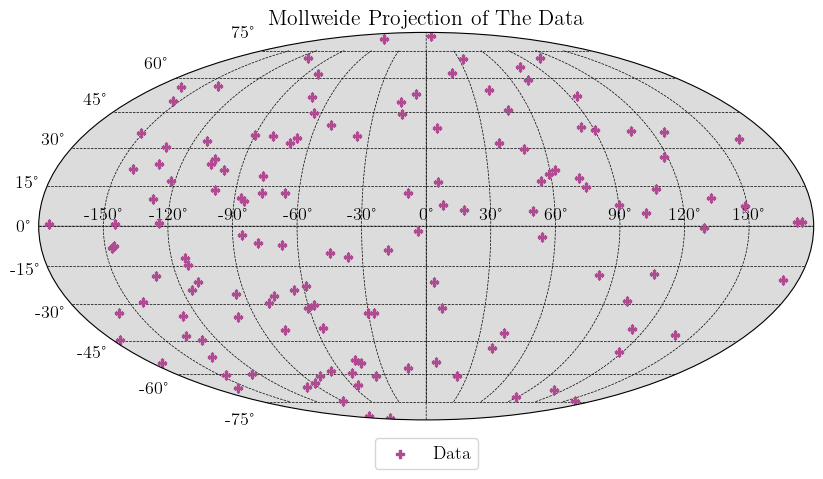

In [643]:
# Plotting the data 
fig, ax = plt.subplots(figsize = (10, 10), subplot_kw = {'projection': 'mollweide'})

projection(azimuth, zenith, ax, 'Mollweide Projection of The Data', colors = colors[5])
ax.legend(loc = 'lower center', bbox_to_anchor = (0.5, -0.15), fontsize = 13)

#### Sampling isotropic data

In [644]:
num_points = len(azimuth)

# Building a function for simulating/sampling isotropic data
def isotropic_data_sampling(seed, num_points):
    np.random.seed(seed)                                # Setting the seed for reproducibility
    sampled_azimuth = np.random.uniform(0, 2 * np.pi, num_points)
    sampled_cos_zenith = np.random.uniform(-1, 1, num_points)
    sampled_zenith = np.arccos(sampled_cos_zenith)
    return sampled_azimuth, sampled_zenith

# Sampling isotropic data
seed = 42
sampled_azimuth, sampled_zenith = isotropic_data_sampling(seed, num_points)

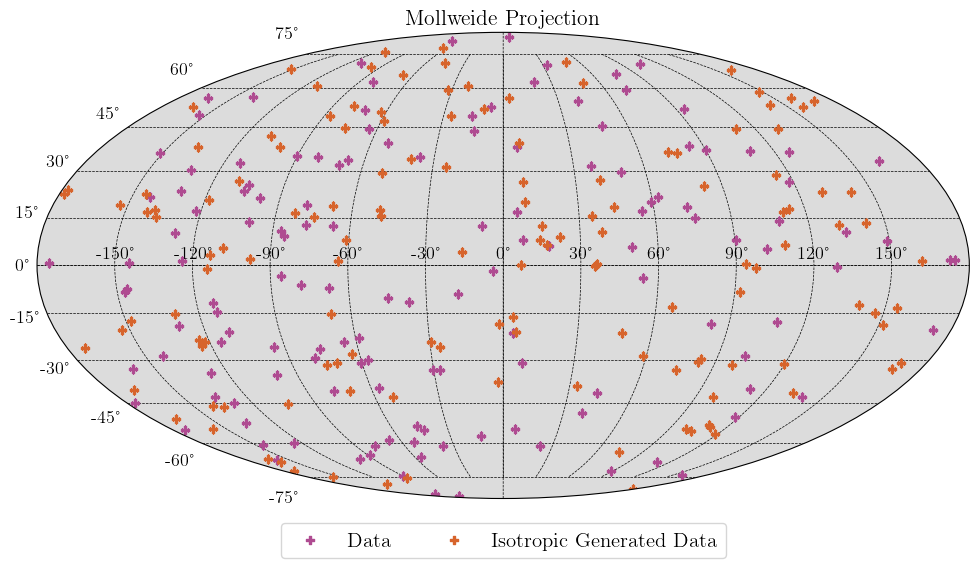

In [645]:
# Plotting the data and simulated isotropic data
fig, ax = plt.subplots(figsize = (10, 10), subplot_kw = {'projection': 'mollweide'})

projection(azimuth, zenith, ax, 'Mollweide Projection', colors[5])
ax.scatter(sampled_azimuth - np.pi, -sampled_zenith + np.pi / 2, marker = 'P', color = colors[4], s = 30, zorder = 2, label = 'Isotropic Generated Data')

ax.legend(loc = 'lower center', bbox_to_anchor = (0.5, -0.15), fontsize = 15, ncols = 2)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/mollweide_projection_final.png', dpi = 300)

#### Testing if the data is actually isotropic

In [646]:
# Two-point correlation function
def two_point_corr_func(azimuth, zenith, bins):
    """ This function counts pairs that are within an angular distance phi. """

    total_num_points = len(azimuth)

    # Each point gets converted into cartesian coordinates 
    r = 1                                                           # Unit vectors 
    Nx = r * np.cos(azimuth) * np.sin(zenith)                       # x-component
    Ny = r * np.sin(azimuth) * np.sin(zenith)                       # y-component
    Nz = r * np.cos(zenith)                                         # z-component

    # Defining a range of cos phi's (x-axis)
    cos_phi_bins = np.linspace(-1, 1, bins)

    # Making an array to store angular distance pairs, i.e. all cos(phi_ij)
    cos_phi_ij_arr = []

    for i in range(0, total_num_points):
        for j in range(0, i):
            cos_phi_ij = Nx[i] * Nx[j] + Ny[i] * Ny[j] + Nz[i] * Nz[j]
            cos_phi_ij_arr.append(cos_phi_ij)

    # Making an array to store the two-point auto-correlation function (y-values)
    y_values = []

    for i in range(bins):
        heaviside = np.heaviside(cos_phi_ij_arr - cos_phi_bins[i], 0)                               # Equal to 1 for x >= 0, equal to 0 for x < 0
        two_point = (2 / (total_num_points * (total_num_points - 1))) * np.sum(heaviside)           # Two-point auto-correlation function 
        y_values.append(two_point)

    # Calculating the isotropic prediction 
    prediction_iso = 1/2 * (1 - cos_phi_bins)                                                       # Cumulative two-point auto-correlation function for perfect isotropic data

    return cos_phi_bins, y_values, prediction_iso

In [647]:
# Usig the two-point correlation function for both the real data and the simulated data 
x, y, prediction_iso = two_point_corr_func(azimuth, zenith, 100)
x_sim, y_sim, prediction_iso_sim = two_point_corr_func(sampled_azimuth, sampled_zenith, 100)

In [648]:
# Using a KS-test to compare the two-point correlation functions 
# Real data 
ks_stat_real = np.max(np.abs(y - prediction_iso))
print(f'KS-statistic for real data: {ks_stat_real:.4f}')
# Simulated data
ks_stat_sim = np.max(np.abs(y_sim - prediction_iso_sim))
print(f'KS-statistic for simulated data: {ks_stat_sim:.4f}')

KS-statistic for real data: 0.0221
KS-statistic for simulated data: 0.0079


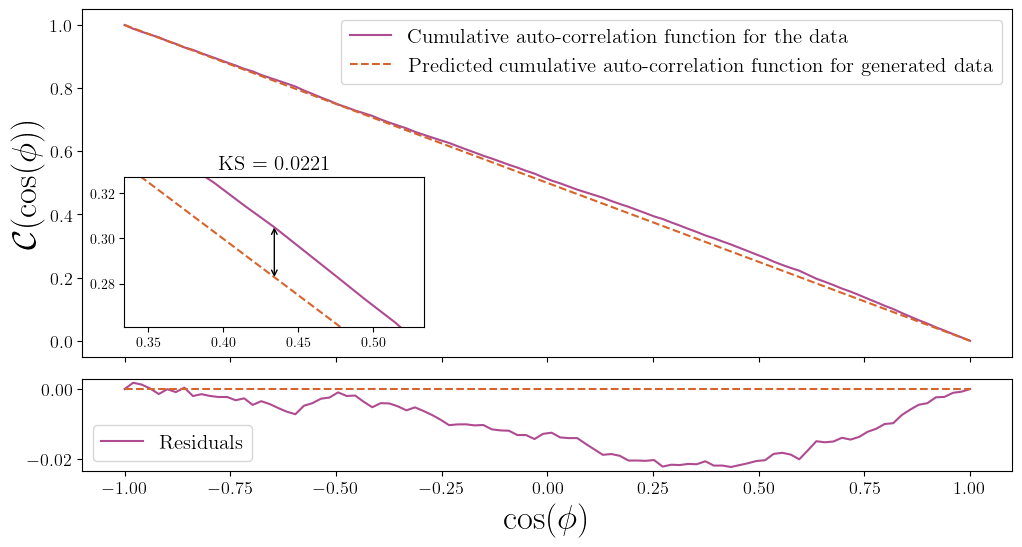

In [649]:
# Plotting the two-point correlation function for the real data and the simulated data
fig, ax = plt.subplots(nrows = 2, figsize = (12, 6), sharex = True, gridspec_kw = {'height_ratios': [1.5, 0.4], 'hspace': 0.1})

ax[0].plot(x, y, color = colors[5], label = 'Cumulative auto-correlation function for the data')
ax[0].plot(x, prediction_iso, color = colors[4], linestyle = 'dashed', label = 'Predicted cumulative auto-correlation function for generated data')
ax[0].legend(loc = 'upper right', fontsize = 15)

# Plotting residuals 
residuals = prediction_iso - y 
ax[1].plot(x, residuals, color = colors[5], label = 'Residuals')
ax[1].hlines(0, x[0], x[-1], color = colors[4], linestyle = '--')
ax[1].legend(fontsize = 15)

# Plotting a zoom-in to see the deviation between the real data and the isotropic data
ax_new = fig.add_axes([0.16, 0.35, 0.25, 0.25])
ax_new.plot(x, y, color = colors[5])
ax_new.plot(x, prediction_iso, color = colors[4], linestyle = 'dashed')

idx = np.argmax(np.abs(residuals))
if residuals[idx] < 0:
    y_min, y_max = prediction_iso[idx] + residuals[idx], y[idx] - residuals[idx]

if residuals[idx] > 0:
    y_min, y_max = y[idx] - residuals[idx], prediction_iso[idx] + residuals[idx]

x_min, x_max = x[idx] - 0.1, x[idx] + 0.1

ax_new.set_xlim(x_min, x_max)
ax_new.set_ylim(y_min, y_max)

sup = ConnectionPatch(xyA = (x[idx], prediction_iso[idx]), xyB = (x[idx], y[idx]), coordsA = ax_new.transData, arrowstyle = '<->', color = 'black')
ax_new.add_artist(sup)
ax_new.set_title(f'KS = {ks_stat_real:.4f}', fontsize = 15)

ax[0].tick_params(axis = 'both', which = 'major')
ax[0].tick_params(axis = 'both', which = 'minor')
ax[1].tick_params(axis = 'both', which = 'major')
ax[1].tick_params(axis = 'both', which = 'minor')
ax_new.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax_new.tick_params(axis = 'both', which = 'minor', labelsize = 10)

ax[1].set_xlabel(r'$\cos(\phi)$', fontsize = 25)
ax[0].set_ylabel(r'$\mathcal{C}(\cos(\phi))$', fontsize = 25)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/two_point_corr_func_data.png', dpi = 300)

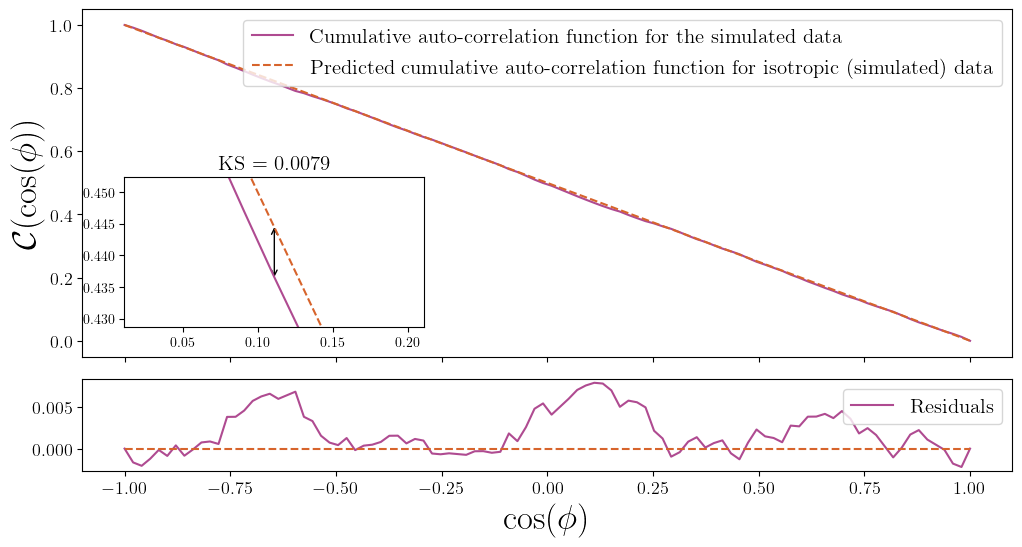

In [650]:
# Plotting the two-point correlation function for the real data and the simulated data
fig, ax = plt.subplots(nrows = 2, figsize = (12, 6), sharex = True, gridspec_kw = {'height_ratios': [1.5, 0.4], 'hspace': 0.1})

ax[0].plot(x_sim, y_sim, color = colors[5], label = 'Cumulative auto-correlation function for the simulated data')
ax[0].plot(x_sim, prediction_iso_sim, color = colors[4], linestyle = 'dashed', label = 'Predicted cumulative auto-correlation function for isotropic (simulated) data')
ax[0].legend(fontsize = 15)

# Plotting residuals 
residuals = prediction_iso_sim - y_sim 
ax[1].plot(x_sim, residuals, color = colors[5], label = 'Residuals')
ax[1].hlines(0, x[0], x[-1], color = colors[4], linestyle = '--')
ax[1].legend(fontsize = 15)

# Plotting a zoom-in to see the deviation between the real data and the isotropic data
ax_new = fig.add_axes([0.16, 0.35, 0.25, 0.25])
ax_new.plot(x_sim, y_sim, color = colors[5])
ax_new.plot(x_sim, prediction_iso_sim, color = colors[4], linestyle = 'dashed')

idx = np.argmax(np.abs(residuals))
if residuals[idx] < 0:
    y_min, y_max = prediction_iso_sim[idx] + residuals[idx], y_sim[idx] - residuals[idx]

if residuals[idx] > 0:
    y_min, y_max = y_sim[idx] - residuals[idx], prediction_iso_sim[idx] + residuals[idx]

x_min, x_max = x_sim[idx] - 0.1, x_sim[idx] + 0.1

ax_new.set_xlim(x_min, x_max)
ax_new.set_ylim(y_min, y_max)

sup = ConnectionPatch(xyA = (x_sim[idx], prediction_iso_sim[idx]), xyB = (x_sim[idx], y_sim[idx]), coordsA = ax_new.transData, arrowstyle = '<->', color = 'black')
ax_new.add_artist(sup)
ax_new.set_title(f'KS = {ks_stat_sim:.4f}', fontsize = 15)

ax[0].tick_params(axis = 'both', which = 'major')
ax[0].tick_params(axis = 'both', which = 'minor')
ax[1].tick_params(axis = 'both', which = 'major')
ax[1].tick_params(axis = 'both', which = 'minor')
ax_new.tick_params(axis = 'both', which = 'major', labelsize = 10)
ax_new.tick_params(axis = 'both', which = 'minor', labelsize = 10)

ax[1].set_xlabel(r'$\cos(\phi)$', fontsize = 25)
ax[0].set_ylabel(r'$\mathcal{C}(\cos(\phi))$', fontsize = 25)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/two_point_corr_func_sim.png', dpi = 300)

In [651]:
# Calculating p-values for 10000 simulations
num_simulations = 10000

ks_stat_values = []
for i in tqdm(range(num_simulations)):
    sampled_azimuth, sampled_zenith = isotropic_data_sampling(i * 10, num_points)
    x, y, prediction_iso = two_point_corr_func(sampled_azimuth, sampled_zenith, 100)
    ks_stat = np.max(np.abs(prediction_iso - y))
    ks_stat_values.append(ks_stat)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [652]:
# Calculating p-values based on the KS-statistics
p_value = np.sum(ks_stat_values >= ks_stat_real) / len(ks_stat_values)
print('p-value:', p_value)

p-value: 0.0026


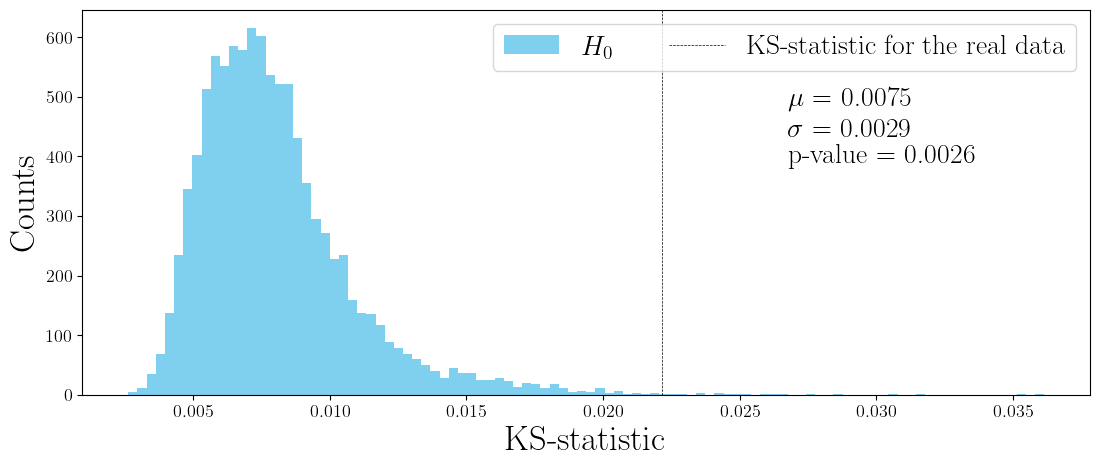

In [702]:
# Plotting all of the KS statistics
fig, ax = plt.subplots(1, 1, figsize = (13, 5))

ax.hist(ks_stat_values, bins = 100, color = colors[2], alpha = 0.5, label = r'$H_{0}$')
ax.axvline(ks_stat_real, color = 'black', linestyle = '--', linewidth = 0.5, label = 'KS-statistic for the real data')

ax.set_xlabel('KS-statistic', fontsize = 25)
ax.set_ylabel('Counts', fontsize = 25)

ax.legend(fontsize = 20, ncols = 2)

median = np.median(ks_stat_values)
std = np.std(ks_stat_values)

ax.annotate(f'$\mu$ = {median:.4f}', xy = (0.7, 0.75), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'$\sigma$ = {std:.4f}', xy = (0.7, 0.67), xycoords = 'axes fraction', fontsize = 20)
ax.annotate(f'p-value = {p_value:.4f}', xy = (0.7, 0.6), xycoords = 'axes fraction', fontsize = 20)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/ks_statistics_2a.png', dpi = 300)

### Problem 2b

In [654]:
# Hypothesis A
def HA_sample(seed, num_points):
    np.random.seed(seed)

    n_uniform = int(0.2 * num_points)           # 20% of the data is uniformly distributed

    # Ranges
    uniform_azimuth = (0.225 * np.pi, 0.725 * np.pi)
    uniform_zenith = (0.30 * np.pi, 1 * np.pi)

    # Sampling uniformly distributed data
    sampled_azimuth_uniform = np.random.uniform(uniform_azimuth[0], uniform_azimuth[1], n_uniform)
    sampled_zenith_uniform = np.random.uniform(uniform_zenith[0], uniform_zenith[1], n_uniform)

    # Sampling isotropic data (the rest of the data, 80%)
    isotropic_azimuth = np.random.uniform(0, 2 * np.pi, num_points - n_uniform)
    isotropic_cos_zenith = np.random.uniform(-1, 1, num_points - n_uniform)
    isotropic_zenith = np.arccos(isotropic_cos_zenith)

    # Combining the data
    azimuth = np.concatenate((sampled_azimuth_uniform, isotropic_azimuth))
    zenith = np.concatenate((sampled_zenith_uniform, isotropic_zenith))

    return azimuth, zenith

# Hypothesis B
def HB_sample(seed, num_points):
    np.random.seed(seed)

    n_uniform = int(0.15 * num_points)           # 15% of the data is uniformly distributed 

    # Ranges
    uniform_azimuth = (0 * np.pi, 1 * np.pi)
    uniform_zenith = (0.50 * np.pi, 1 * np.pi)

    # Sampling uniformly distributed data
    sampled_azimuth_uniform = np.random.uniform(uniform_azimuth[0], uniform_azimuth[1], n_uniform)
    sampled_zenith_uniform = np.random.uniform(uniform_zenith[0], uniform_zenith[1], n_uniform)

    # Sampling isotropic data (the rest of the data, 85%)
    isotropic_azimuth = np.random.uniform(0, 2 * np.pi, num_points - n_uniform)
    isotropic_cos_zenith = np.random.uniform(-1, 1, num_points - n_uniform)
    isotropic_zenith = np.arccos(isotropic_cos_zenith)

    # Combining the data
    azimuth = np.concatenate((sampled_azimuth_uniform, isotropic_azimuth))
    zenith = np.concatenate((sampled_zenith_uniform, isotropic_zenith))

    return azimuth, zenith

In [655]:
# Calculating KS-statistics for the two hypotheses
def ks_stat_HA(samples, num_points):
    ks_stat_values = []

    print('Currently sampling HA...')
    for i in tqdm(range(samples)):
        sampled_azimuth, sampled_zenith = HA_sample(i * 10, num_points)

        x, y, prediction_iso = two_point_corr_func(sampled_azimuth, sampled_zenith, 100)

        ks_stat = np.max(np.abs(prediction_iso - y))
        ks_stat_values.append(ks_stat)

    return ks_stat_values

def ks_stat_HB(samples, num_points):
    ks_stat_values = []

    print('Currently sampling HB...')
    for i in tqdm(range(samples)):
        sampled_azimuth, sampled_zenith = HB_sample(i * 10, num_points)

        x, y, prediction_iso = two_point_corr_func(sampled_azimuth, sampled_zenith, 100)

        ks_stat = np.max(np.abs(prediction_iso - y))
        ks_stat_values.append(ks_stat)

    return ks_stat_values

In [656]:
num_simulations = 10000
ks_stat_values_HA = ks_stat_HA(num_simulations, num_points)
ks_stat_values_HB = ks_stat_HB(num_simulations, num_points)

Currently sampling HA...


  0%|          | 0/10000 [00:00<?, ?it/s]

Currently sampling HB...


  0%|          | 0/10000 [00:00<?, ?it/s]

In [657]:
# Calculating p-values w.r.t. isotropic data
p_value_HA = np.sum(ks_stat_values >= np.median(ks_stat_values_HA)) / len(ks_stat_values)
p_value_HB = np.sum(ks_stat_values >= np.median(ks_stat_values_HB)) / len(ks_stat_values)

print('p-value HA:', p_value_HA, '(w.r.t. isotropic data)')
print('p-value HB:', p_value_HB, '(w.r.t. misotropic data)')

# Calculating p-values w.r.t. the real data 
p_value_HA_real = np.sum(ks_stat_values_HA >= ks_stat_real) / len(ks_stat_values_HA)
p_value_HB_real = np.sum(ks_stat_values_HB >= ks_stat_real) / len(ks_stat_values_HB)

print('p-value HA:', p_value_HA_real, '(w.r.t. real data)')
print('p-value HB:', p_value_HB_real, '(w.r.t. real data)')

p-value HA: 0.0102 (w.r.t. isotropic data)
p-value HB: 0.0872 (w.r.t. misotropic data)
p-value HA: 0.341 (w.r.t. real data)
p-value HB: 0.1275 (w.r.t. real data)


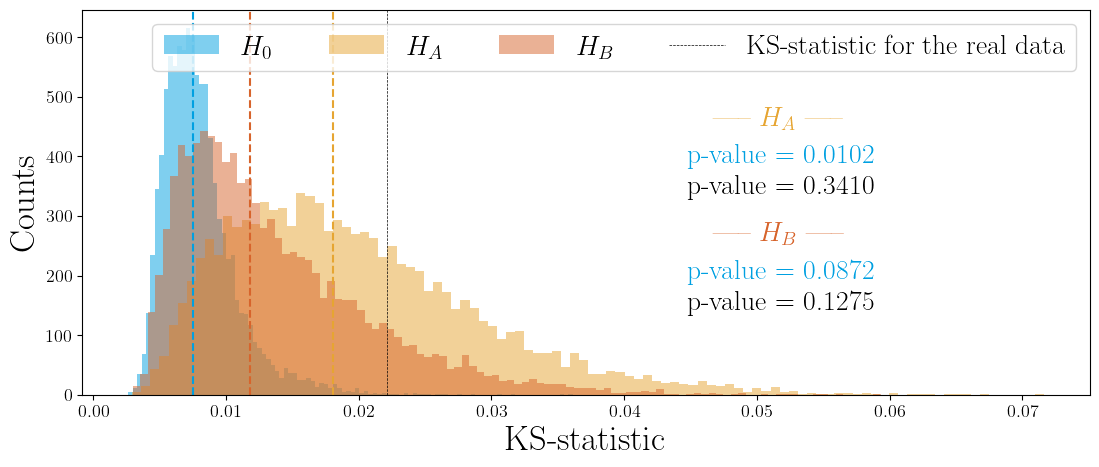

In [658]:
# Plotting the KS statistics for the three hypotheses to compare
fig, ax = plt.subplots(1, 1, figsize = (13, 5))

ax.hist(ks_stat_values, bins = 100, color = colors[2], alpha = 0.5, label = r'$H_{0}$')
median_KS_H0 = np.median(ks_stat_values)
ax.axvline(median_KS_H0, color = colors[2], linestyle = '--')

# HA hypothesis
ax.hist(ks_stat_values_HA, bins = 100, color = colors[3], alpha = 0.5, label = r'$H_{A}$')
median_KS_HA = np.median(ks_stat_values_HA)
ax.axvline(median_KS_HA, color = colors[3], linestyle = '--')

# HB hypothesis
ax.hist(ks_stat_values_HB, bins = 100, color = colors[4], alpha = 0.5, label = r'$H_{B}$')
median_KS_HB = np.median(ks_stat_values_HB)
ax.axvline(median_KS_HB, color = colors[4], linestyle = '--')

ax.axvline(ks_stat_real, color = 'black', linestyle = '--', linewidth = 0.5, label = 'KS-statistic for the real data')

ax.annotate(r'----- $H_{A}$ -----', xy = (0.625, 0.7), xycoords = 'axes fraction', fontsize = 20, color = colors[3])
ax.annotate(f'p-value = {p_value_HA:.4f}', xy = (0.6, 0.6), xycoords = 'axes fraction', fontsize = 20, color = colors[2])
ax.annotate(f'p-value = {p_value_HA_real:.4f}', xy = (0.6, 0.52), xycoords = 'axes fraction', fontsize = 20, color = 'black')

ax.annotate(r'----- $H_{B}$ -----', xy = (0.625, 0.4), xycoords = 'axes fraction', fontsize = 20, color = colors[4])
ax.annotate(f'p-value = {p_value_HB:.4f}', xy = (0.6, 0.3), xycoords = 'axes fraction', fontsize = 20, color = colors[2])
ax.annotate(f'p-value = {p_value_HB_real:.4f}', xy = (0.6, 0.22), xycoords = 'axes fraction', fontsize = 20, color = 'black')

ax.set_xlabel('KS-statistic', fontsize = 25)
ax.set_ylabel('Counts', fontsize = 25)

ax.legend(fontsize = 20, ncols = 4)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/ks_statistics_2b.png', dpi = 300)

## Problem 3

### Problem 3a

In [659]:
# First defining the beta dsitribution 
alpha, beta_parameter = 7.7, 30

# Probability of chocolate
p_choco = beta.cdf(0.17, alpha, beta_parameter)         # Since the fraction of cheese must be >0.83 for the person to hve chocolate
print('Probability of chocolate:', p_choco)

# Calculating the expected number of meals with chocolate
n_meals = 200
expected_choco = n_meals * p_choco
print('Expected number of meals with chocolate:', expected_choco)

Probability of chocolate: 0.3221867597180812
Expected number of meals with chocolate: 64.43735194361624


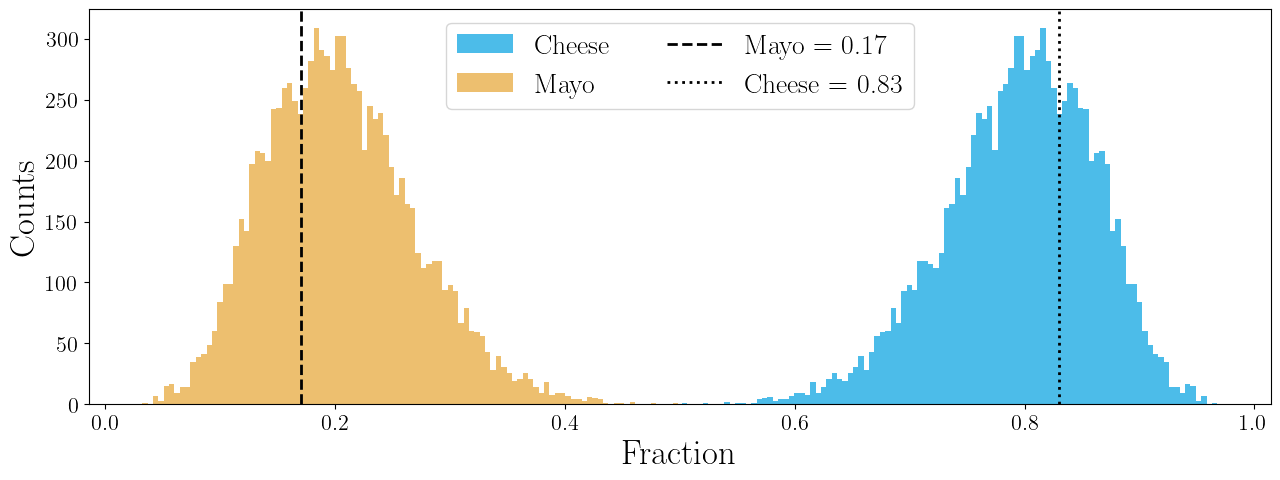

In [660]:
samples = 10000

# Sampling
mayo_samples = beta.rvs(alpha, beta_parameter, size=samples)
cheese_samples = 1 - mayo_samples

# Plot
fig, ax = plt.subplots(1, 1, figsize=(13, 5))

# Histograms
ax.hist(cheese_samples, bins=100, color=colors[2], alpha=0.7, label='Cheese')
ax.hist(mayo_samples, bins=100, color=colors[3], alpha=0.7, label='Mayo')

# Threshold lines
ax.axvline(0.17, color='black', linestyle='--', linewidth=2, label='Mayo = 0.17')
ax.axvline(0.83, color='black', linestyle=':', linewidth=2, label='Cheese = 0.83')

# Labels and legend
ax.set_xlabel('Fraction', fontsize=25)
ax.set_ylabel('Counts', fontsize=25)
ax.tick_params(axis='both', labelsize=16)
ax.legend(loc='upper center', fontsize=20, ncol=2)

# Save
plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/beta_distribution_prob_3a.png', dpi=300)


### Problem 3b

In [711]:
meal_names = ['Mayo&Cheese', 'FrozenPizza', 'CornishPasties', 'Rice&Eggs', 'Spaghetti']
hot_sauce_means = ['Rice&Eggs', 'Spaghetti']
meal_prob = [0.20, 0.25, 0.10, 0.33, 0.12]

days, runs = 365, 10000

# Parameter for the chi-squared distribution 
k = 11

# Defining thredsholds
cheese_to_choco = 0.83
rice_to_choco = 21.4            # SHU for rice and eggs
spaghetti_to_choco = 8.2        # SHU for spaghetti

In [712]:
# Running a Monte Carlo simulation 
choco_counts = []

for _ in tqdm(range(runs)):
    # Initializing the counts
    choco_count = 0
    had_hot_sauce_prev = False              # To keep track of the previous day

    for _ in range(days):
        meal = np.random.choice(meal_names, p = meal_prob)      # Choosing a random meal

        has_choco = False
        has_hot_sauce = False

        if meal == 'Mayo&Cheese':
            mayo_ratio = np.random.beta(alpha, beta_parameter)
            cheese_ratio = 1 - mayo_ratio
            has_choco = cheese_ratio > cheese_to_choco

        elif meal == 'FrozenPizza':
            has_choco = True

        elif meal == 'CornishPasties':
            has_choco = False

        elif meal == 'Rice&Eggs':
            has_hot_sauce = True
            shu = stats.chi2.rvs(k)
            if had_hot_sauce_prev:
                has_choco = False
            else:
                has_choco = shu > rice_to_choco

        elif meal == 'Spaghetti':
            has_hot_sauce = True
            shu = stats.chi2.rvs(k)
            if had_hot_sauce_prev:
                has_choco = False
            else:
                has_choco = shu > spaghetti_to_choco

        if has_choco:
            choco_count += 1

        had_hot_sauce_prev = has_hot_sauce          # Updating the previous day (memory)

    choco_counts.append(choco_count)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [713]:
# Printing the statstics
choco_counts = np.array(choco_counts)
mean_choco = np.mean(choco_counts)
inter_quartile_range = np.percentile(choco_counts, 75) - np.percentile(choco_counts, 25)

#print('Expected number of days with chocolate per year:', choco_counts)
print('Expected mean number of days with chocolate per year:', mean_choco)
print('Inter-quartile range:', inter_quartile_range)

Expected mean number of days with chocolate per year: 133.4918
Inter-quartile range: 13.0


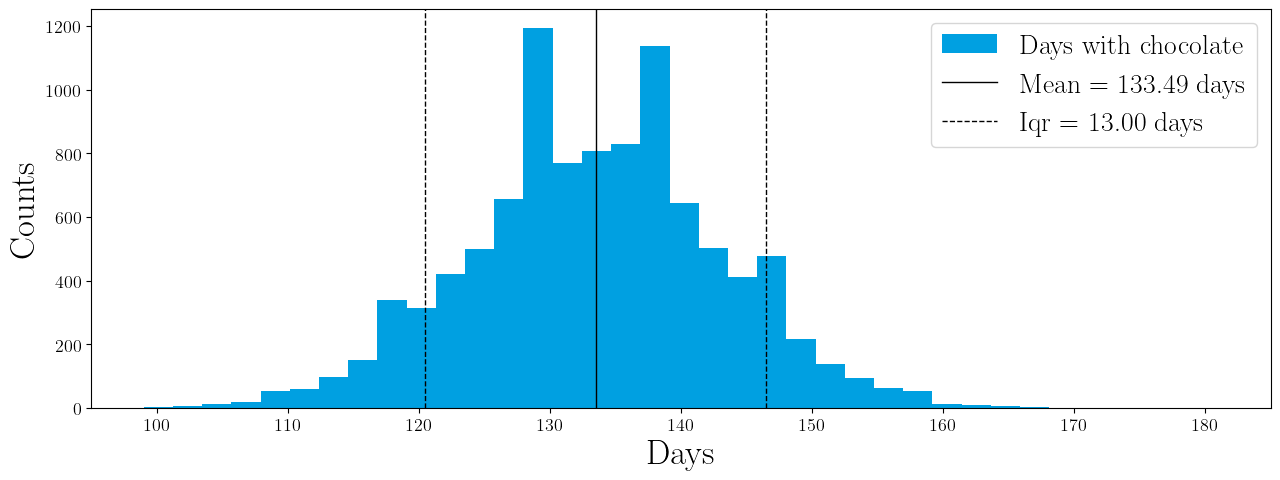

In [714]:
# Plotting
fig, ax = plt.subplots(1, 1, figsize = (13, 5))

ax.hist(choco_counts, bins = 35, color = colors[2], label = 'Days with chocolate')
ax.axvline(mean_choco, color = 'black', linestyle = '-', linewidth = 1, label = f'Mean = {mean_choco:.2f} days')
ax.axvline(mean_choco - inter_quartile_range, color = 'black', linestyle = '--', linewidth = 1, label = f'Iqr = {inter_quartile_range:.2f} days')
ax.axvline(mean_choco + inter_quartile_range, color = 'black', linestyle = '--', linewidth = 1)

ax.set_xlabel('Days', fontsize = 25)
ax.set_ylabel('Counts', fontsize = 25)
ax.set_xlim(95, 185)

ax.legend(loc = 'upper right', fontsize = 20)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/monte_carlo_prob_3b.png', dpi = 300)

### Problem 3c

In [715]:
# Calculating the probability of having spaghetti for 3 days in a row
successes = 0

for _ in tqdm(range(runs)):
    meals = np.random.rand(days) < meal_prob[4]
    # Checking if there are three days in a row with spaghetti
    for i in range(days - 2):
        if np.all(meals[i:i+3]):
            successes += 1
            break

# Estimate probability
p = successes / runs
print('Probability of having spaghetti for 3 days in a row:', p)

  0%|          | 0/10000 [00:00<?, ?it/s]

Probability of having spaghetti for 3 days in a row: 0.4183


## Problem 4

In [716]:
prob_4_data = np.genfromtxt('https://www.nbi.dk/~koskinen/Teaching/AdvancedMethodsInAppliedStatistics2025/data/Exam_2025_Prob4.txt', skip_header = 1)

# Sorting
data_sorted_prob_4 = np.sort(prob_4_data)

x_lim = (min(data_sorted_prob_4), max(data_sorted_prob_4))
x_range = np.linspace(x_lim[0], x_lim[1], 1000)

In [717]:
# Defining Gaussian PDF
def gauss_PDF(x, mu, sigma):
    return stats.norm.pdf(x, mu, sigma)

#### Hypothesis A: Double Gauss

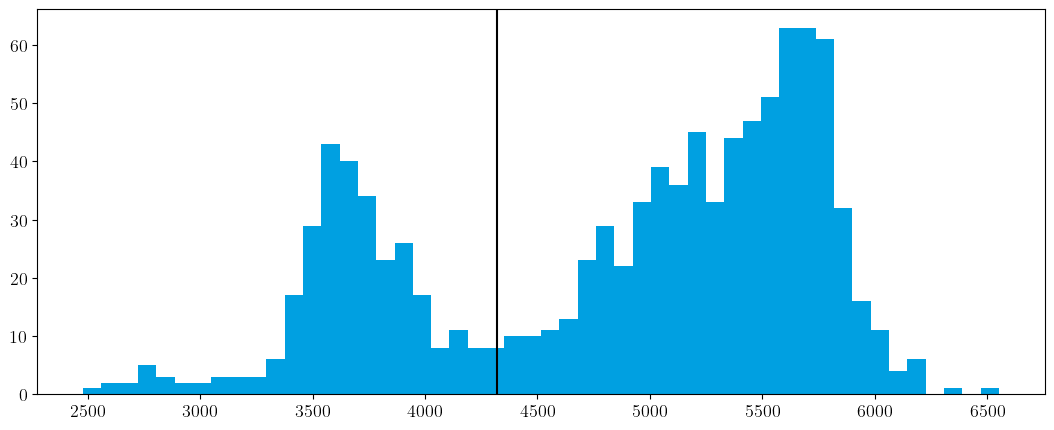

In [718]:
num_of_bins = 50

# Plotting
fig, ax = plt.subplots(1, 1, figsize = (13, 5))

histogram = ax.hist(data_sorted_prob_4, bins = num_of_bins, color = colors[2], label = 'Data')
ax.axvline(data_sorted_prob_4[290], color = 'black')

bins_used, bin_widths_used = histogram[1], histogram[1][1] - histogram[1][0]

In [719]:
# Fitting
# ---- Gauss 1 ----
gauss_1_range = data_sorted_prob_4[0:290]
fit_params_gauss_1, fit_params_err_gauss_1, neg_LLH_gauss_1 = unbinned_likelihood(gauss_1_range, gauss_PDF, [3650, 100], ['mu', 'sigma'])
chi_gauss_1, p_gauss_1, bin_width_gauss_1 = chi_squared_test(gauss_1_range, gauss_PDF, fit_params_gauss_1, bins_used)
y_values_gauss_1 = gauss_PDF(x_range, *fit_params_gauss_1) * len(gauss_1_range) * bin_width_gauss_1

# ---- Gauss 2 ----
gauss_2_range = data_sorted_prob_4[290:]
fit_params_gauss_2, fit_params_err_gauss_2, neg_LLH_gauss_2 = unbinned_likelihood(gauss_2_range, gauss_PDF, [5350, 100], ['mu', 'sigma'])
chi_gauss_2, p_gauss_2, bin_width_gauss_2 = chi_squared_test(gauss_2_range, gauss_PDF, fit_params_gauss_2, bins_used)
y_values_gauss_2 = gauss_PDF(x_range, *fit_params_gauss_2) * len(gauss_2_range) * bin_width_gauss_2

Reduced chi-squared: 5.8931, p-value: 0.0000
Reduced chi-squared: 3.9291, p-value: 0.0000


In [720]:
# Combining the two Gaussians (summing the PDFs and normalizing)
combined_double_gauss = y_values_gauss_1 + y_values_gauss_2
combined_double_gauss /= np.trapz(combined_double_gauss, x_range)

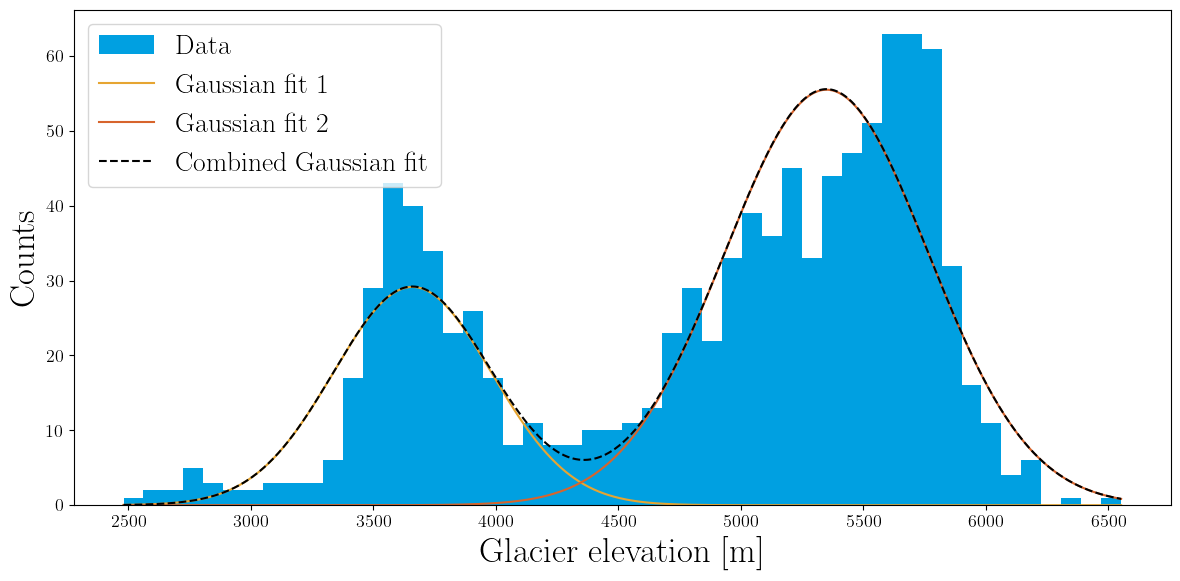

In [721]:
# Plotting result
fig, ax = plt.subplots(1, 1, figsize = (12, 6))

ax.hist(data_sorted_prob_4, bins = num_of_bins, color = colors[2], label = 'Data')

# Plotting the two Gaussians
ax.plot(x_range, y_values_gauss_1, color = colors[3], linewidth = 1.5, label = 'Gaussian fit 1')
ax.plot(x_range, y_values_gauss_2, color = colors[4], linewidth = 1.5, label = 'Gaussian fit 2')

# Plotting the combined Gaussian
ax.plot(x_range, combined_double_gauss * len(data_sorted_prob_4) * bin_widths_used, color = 'black', linestyle = '--', label = 'Combined Gaussian fit')

ax.legend(fontsize = 20)

ax.set_xlabel('Glacier elevation [m]', fontsize = 25)
ax.set_ylabel('Counts', fontsize = 25)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/double_gaussian_prob_4a1.png', dpi = 300)

### Hypothesis B: Triple Gauss

In [722]:
def double_gauss_pdf_data(x):
    pdf = gauss_PDF(x, *fit_params_gauss_1) * len(gauss_1_range) * bin_width_gauss_1 + gauss_PDF(x, *fit_params_gauss_2) * len(gauss_2_range) * bin_width_gauss_2
    pdf_norm = pdf / np.trapz(pdf, x)
    return pdf_norm

# Treating the second Gaussian as a double Gaussian instead of single
def double_gauss_pdf(x, mu_1, sigma_1, mu_2, sigma_2):
    return (gauss_PDF(x, mu_1, sigma_1) + gauss_PDF(x, mu_2, sigma_2)) / 2

In [723]:
# Fitting the double Gaussian
fit_params_double_gauss, fit_params_err_double_gauss, neg_LLH_double_gauss = unbinned_likelihood(gauss_2_range, double_gauss_pdf, [3650, 100, 5350, 100], ['mu_1', 'sigma_1', 'mu_2', 'sigma_2'])
chi_double_gauss, p_double_gauss, bin_width_double_gauss = chi_squared_test(gauss_2_range, double_gauss_pdf, fit_params_double_gauss, bins_used)
y_values_double_gauss = double_gauss_pdf(x_range, *fit_params_double_gauss) * len(gauss_2_range) * bin_width_double_gauss

Reduced chi-squared: 3.5112, p-value: 0.0000


In [724]:
# Combining all three Gaussians (summing the PDFs and normalizing)
combined_triple_gauss = y_values_gauss_1 + y_values_double_gauss
combined_triple_gauss /= np.trapz(combined_triple_gauss, x_range)

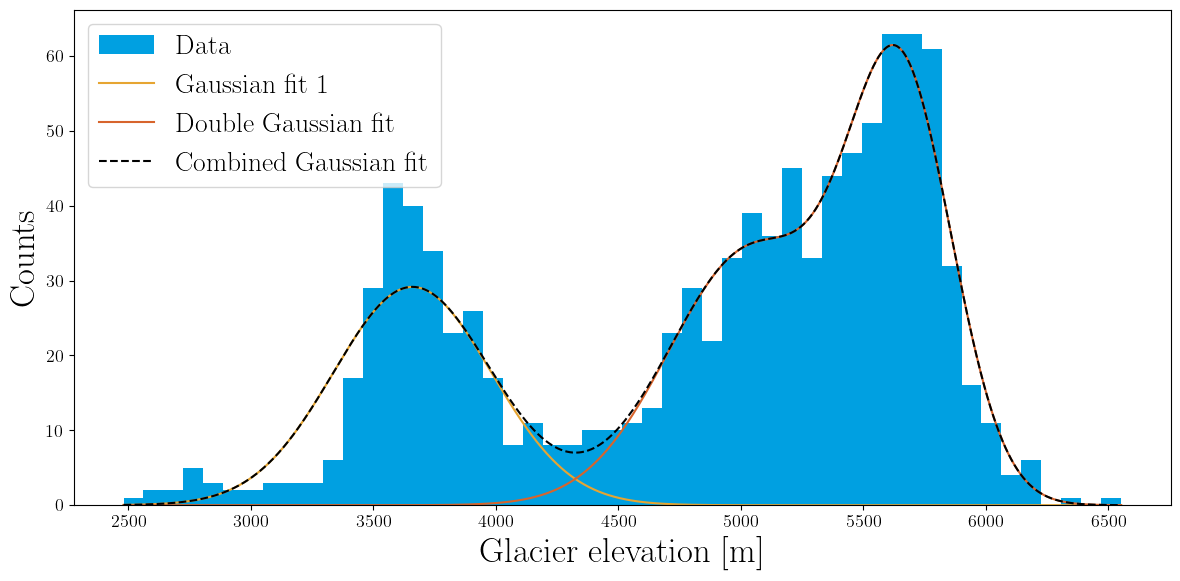

In [725]:
# Plotting
fig, ax = plt.subplots(1, 1, figsize = (12, 6))

ax.hist(data_sorted_prob_4, bins = num_of_bins, color = colors[2], label = 'Data')

# Plotting the two Gaussians
ax.plot(x_range, y_values_gauss_1, color = colors[3], linewidth = 1.5, label = 'Gaussian fit 1')
ax.plot(x_range, y_values_double_gauss, color = colors[4], linewidth = 1.5, label = 'Double Gaussian fit')

# Plotting the combined Gaussian
ax.plot(x_range, combined_triple_gauss * len(data_sorted_prob_4) * bin_widths_used, color = 'black', linestyle = '--', label = 'Combined Gaussian fit')

ax.legend(fontsize = 20)

ax.set_xlabel('Glacier elevation [m]', fontsize = 25)
ax.set_ylabel('Counts', fontsize = 25)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/triple_gaussian_prob_4a2.png', dpi = 300)

In [726]:
def triple_gauss_pdf(x):
    pdf = gauss_PDF(x, *fit_params_gauss_1) * len(gauss_1_range) * bin_width_gauss_1 + double_gauss_pdf(x, *fit_params_double_gauss) * len(gauss_2_range) * bin_width_double_gauss
    pdf_norm = pdf / np.trapz(pdf, x)
    return pdf_norm

In [727]:
def chi_squared_test_new(data, pdf, num_parameters, num_bins):
    counts, bins = np.histogram(data, bins = num_bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_width = bins[1] - bins[0]

    # Removing bins, which don't have any counts
    x = bin_centers[counts > 0]
    y = counts[counts > 0]

    # Calculating the expected values
    expected_values = pdf(x) * len(data) * bin_width

    dof = len(x) - num_parameters

    chi_squared = np.sum((y - expected_values) ** 2 / expected_values)
    chi_reduced = chi_squared / dof
    p = stats.chi2.sf(chi_squared, dof)
    print(f'The reduced Chi2 is: {chi_reduced:.4f} with a p-value of: {p:.4f}')

    return chi_squared, p, bin_width, x, y, expected_values


In [728]:
print(len(bins_used))

51


In [729]:
# Getting the chi2 and p-values for full data range
chi_triple_gauss, p_triple_gauss, bin_width_triple_gauss, x_triple_gauss, y_triple_gauss, expected_values_triple_gauss = chi_squared_test_new(data_sorted_prob_4, triple_gauss_pdf, 4, bins_used)
chi_double_gauss, p_double_gauss, bin_width_double_gauss, x_double_gauss, y_double_gauss, expected_values_double_gauss = chi_squared_test_new(data_sorted_prob_4, double_gauss_pdf_data, 4, bins_used)


The reduced Chi2 is: 4.4118 with a p-value of: 0.0000
The reduced Chi2 is: 4.6156 with a p-value of: 0.0000


### Doing Monte Carlo and KS-test to compare hypotheses

In [730]:
# Functions needed to run the Monte Carlo simulation
def MC_double_gauss(x):
    pdf = gauss_PDF(x, *fit_params_gauss_1) * len(gauss_1_range) * bin_width_gauss_1 + gauss_PDF(x, *fit_params_gauss_2) * len(gauss_2_range) * bin_width_gauss_2
    return pdf

def MC_triple_gauss(x):
    pdf = gauss_PDF(x, *fit_params_gauss_1) * len(gauss_1_range) * bin_width_gauss_1 + double_gauss_pdf(x, *fit_params_double_gauss) * len(gauss_2_range) * bin_width_double_gauss
    return pdf

In [731]:
# Using the accept-reject method 
def accept_reject_MC(xmin, xmax, func, num_points):
    # Generating random numbers within the range
    x = np.linspace(xmin, xmax, num_points)
    X_rand = np.random.uniform(xmin, xmax, num_points)
    Y_rand = np.random.uniform(min(func(x)), max(func(x)), num_points)

    # Accepting and rejecting
    f_x = func(X_rand)
    accepted = Y_rand <= f_x
    X_accepted = X_rand[accepted]
    Y_accepted = Y_rand[accepted]

    efficiency = len(X_accepted) / len(X_rand)
    return X_accepted, Y_accepted, efficiency

In [732]:
x_min, x_max, N = min(data_sorted_prob_4), max(data_sorted_prob_4), len(data_sorted_prob_4)

KS_values_double_gauss = []
KS_values_triple_gauss = []


for _ in tqdm(range(10000)):
    X_accepted_double_gauss, Y_accepted_double_gauss, efficiency_double_gauss = accept_reject_MC(x_min, x_max, MC_double_gauss, N)
    KS_values_double_gauss.append(stats.ks_2samp(X_accepted_double_gauss, data_sorted_prob_4)[1])

    X_accepted_triple_gauss, Y_accepted_triple_gauss, efficiency_triple_gauss = accept_reject_MC(x_min, x_max, MC_triple_gauss, N)
    KS_values_triple_gauss.append(stats.ks_2samp(X_accepted_triple_gauss, data_sorted_prob_4)[1])

  0%|          | 0/10000 [00:00<?, ?it/s]

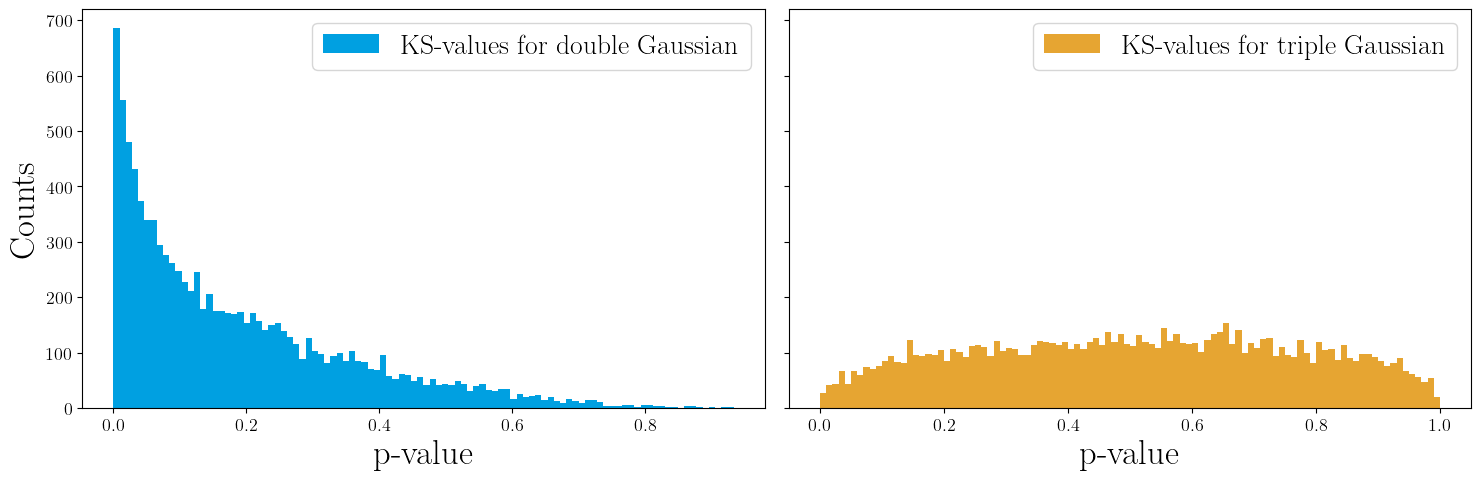

In [733]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize = (15, 5), sharey = True)

ax[0].hist(KS_values_double_gauss, bins = 100, color = colors[2], label = 'KS-values for double Gaussian')
ax[1].hist(KS_values_triple_gauss, bins = 100, color = colors[3], label = 'KS-values for triple Gaussian')

ax[0].set_xlabel('p-value', fontsize = 25)
ax[1].set_xlabel('p-value', fontsize = 25)
ax[0].set_ylabel('Counts', fontsize = 25)

ax[0].legend(fontsize = 20)
ax[1].legend(fontsize = 20)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/monte_carlo_prob_4b.png', dpi = 300)

### Problem 5

In [734]:
prob_5_data = np.genfromtxt('https://www.nbi.dk/~koskinen/Teaching/AdvancedMethodsInAppliedStatistics2025/data/Exam_2025_Problem5.txt')

In [735]:
# Finding the threshold, of the data that corresponds to a one-sided p-value of 4.55%
# Sorting the data
prob_5_data = np.sort(prob_5_data)

crit_value = np.percentile(prob_5_data, 94.45)
print('Critical value:', crit_value)

chi2_critial = stats.chi2.ppf(0.9445, 5)
print('Chi2 critical:', chi2_critial)

Critical value: 15.004952058499999
Chi2 critical: 10.79966235789997


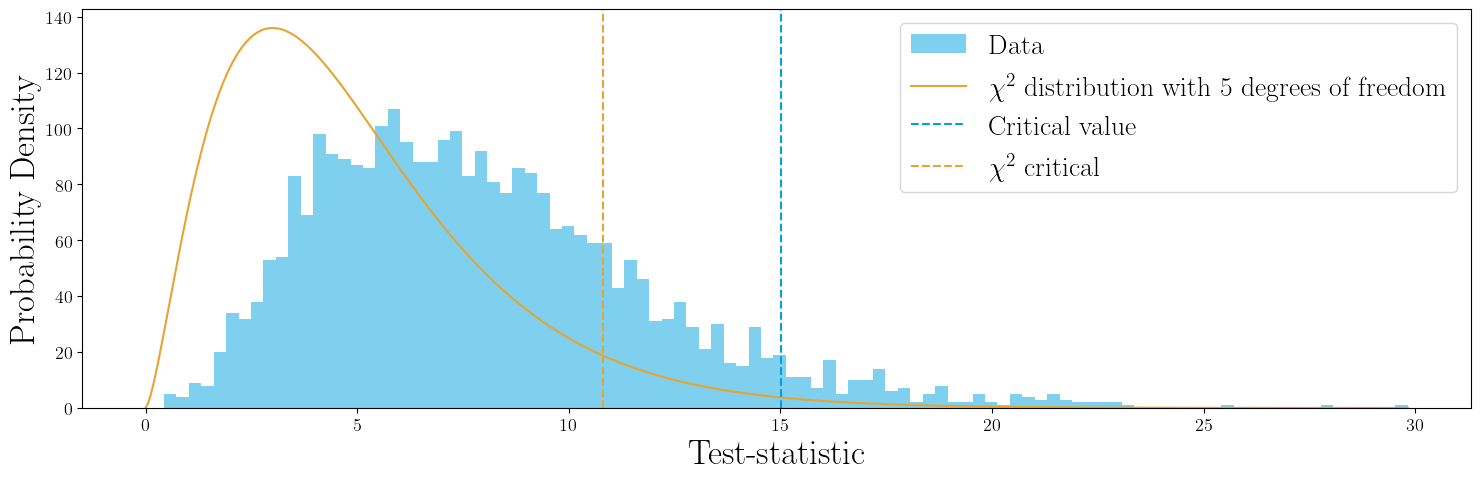

In [736]:
# Plotting the data
fig, ax = plt.subplots(1, 1, figsize = (15, 5))

hist = ax.hist(prob_5_data, bins = 100, color = colors[2], alpha = 0.5, label = 'Data')
bins_used, bin_widths_used = hist[1], hist[1][1] - hist[1][0]

x = np.linspace(0, max(prob_5_data), 500)
y = stats.chi2.pdf(x, 5)
ax.plot(x, y * len(prob_5_data) * bin_widths_used, color = colors[3], linestyle = '-', label = r'$\chi^{2}$ distribution with 5 degrees of freedom')

ax.axvline(crit_value, color = colors[2], linestyle = '--', label = 'Critical value')
ax.axvline(chi2_critial, color = colors[3], linestyle = '--', label = r'$\chi^{2}$ critical')

ax.legend(fontsize = 20)
ax.set_xlabel('Test-statistic', fontsize = 25)
ax.set_ylabel('Probability Density', fontsize = 25)

plt.tight_layout()
plt.savefig('/Users/ChamillaTerp/Dropbox/Skole/Master/Advanced Methods in Applied Statistics/Exam 2025/chi2_distribution_prob_5.png', dpi = 300)